# 🎨 Week 3: Seaborn 数据可视化入门

> **我们的目标**: 让数据“说话”。
> 之前我们是“数据清洁工”，现在我们要变成“数据艺术家”。
> 
> **核心理念**: 
> *   **Excel**: 选数据 -> 插入图表。
> *   **Seaborn**: 清洗数据 (Tidy Data) -> 映射 (Mapping) -> 画图。


## ⛽️ 模块 0: 函数加油站 (Function Cheat Sheet)

| 图表类型 | 你的问题 (Business Question) | Seaborn 函数 | 关键参数 (Key Args) |
| :--- | :--- | :--- | :--- |
| **直方图** | “这群人的年龄分布在哪里？集中的多吗？” | `sns.histplot` | `data=df, x='age'` |
| **散点图** | “身高越高，体重越重吗？” (看关系) | `sns.scatterplot` | `data=df, x='height', y='weight'` |
| **箱线图** | “谁是异常值？哪个组的波动大？” | `sns.boxplot` | `data=df, x='gender', y='weight'` |
| **画布设置** | “图太小了看不清” | `plt.figure` | `figsize=(10, 6)` |

## 🗺️ 模块 1: 概念映射 (Excel vs Python)

### 1. Excel 的逻辑
*   你有一大坨数据，鼠标选中其中的两列。
*   点击“插入 -> 散点图”。

### 2. Seaborn 的逻辑
*   你只需要告诉代码 **“列名”** 叫什么。
*   `sns.scatterplot(data=df, x='height', y='weight')`
*   **画图也是一种查询**: 你不是在画画，你是在对数据提问。

## 🛠️ 模块 2: 数据准备 (Gym Dataset)
我们来模拟一个健身房的会员数据。
数据里会有一些**脏数据**（比如体重是负数，或者是绿巨人），这是为了让你练习 **“先清洗，再画图”**。

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 设置个好看的风格
sns.set_theme(style="whitegrid")

# Mac 专用：设置字体为 "Arial Unicode MS"
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 

# 这个是解决由负号变成了方块的问题
plt.rcParams['axes.unicode_minus'] = False 

# 1. 构造 Mock 数据
np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 60, size=n),              # 年龄 18-60
    'gender': np.random.choice(['M', 'F'], size=n),        # 性别
    'height': np.random.normal(170, 10, size=n),           # 身高 (cm)
    'weight': np.random.normal(70, 15, size=n),            # 体重 (kg)
    'membership_days': np.random.randint(1, 1000, size=n)  # 入会天数
}
df = pd.DataFrame(data)

# 2. 手动加点脏数据 (Noise)
# a. 两个超级胖子 (异常值)
df.loc[0, 'weight'] = 300
df.loc[1, 'weight'] = 280
# b. 一个体重是负数 (脏数据)
df.loc[2, 'weight'] = -50

print("健身房数据准备就绪！")
df.head()

健身房数据准备就绪！


,age,gender,height,weight,membership_days
0,56,M,172.309537,300.000000,292
1,46,F,161.910631,280.000000,794
2,32,F,180.574235,-50.000000,811
3,25,M,170.513609,93.120565,283
4,38,F,178.724472,57.581604,69


## ⚔️ 模块 3: 分级挑战

### Level 1: 基础分布 (Distribution)
**需求**: 
我想看看到底是年轻人多还是老年人多？
请画出 `age` 的**直方图 (Histogram)**。

*   提示: `sns.histplot(data=df, x='...')`

Text(0.5, 1.0, '年龄分布直方图')

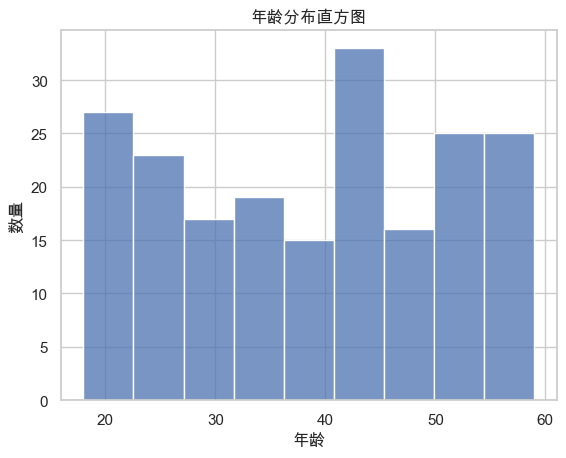

In [2]:
# [你的代码]
sns.histplot(data=df,x='age')
plt.xlabel('年龄')
plt.ylabel('数量')
plt.title('年龄分布直方图')

### Level 2: 关系探索 (Relationship)
**需求**: 
大家常说“太胖可能是因为太高”。真的吗？
请画出 **身高 (x)** 和 **体重 (y)** 的**散点图 (Scatterplot)**。

*   进阶: 能不能用颜色 (`hue`) 来区分男女？

Text(0.5, 1.0, '身高体重散点图——区分性别')

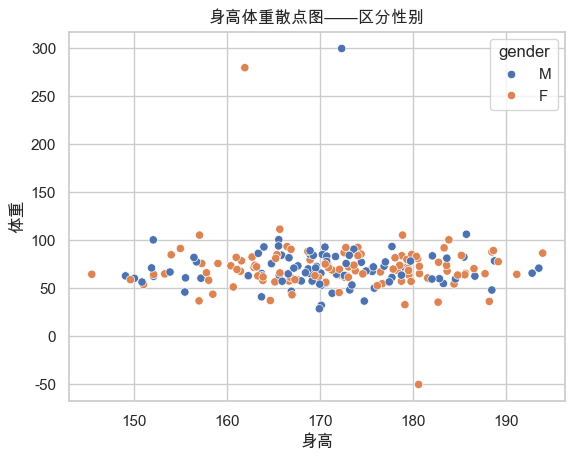

In [3]:
# [你的代码]
sns.scatterplot(data=df,x='height',y='weight',hue='gender')
plt.xlabel('身高')
plt.ylabel('体重')
plt.title('身高体重散点图——区分性别')

### Level 3: 清洗 + 可视化 (The Real World)
**需求**: 
刚才的散点图里，你是不是看到几个点“飞出去了”？（300kg的大胖子，还有-50kg的幽灵）
这些异常值会毁了我们的分析。

请执行以下步骤：
1.  **清洗**: 过滤掉 `weight > 200` 或者 `weight < 0` 的人，生成一个新表 `df_clean`。
2.  **对比**: 用新表画一个 **箱线图 (Boxplot)**，对比不同性别的 **体重分布**。

*   提示: `filtered_df = df[(...) & (...)]`

Text(0.5, 1.0, '区分性别年龄分布箱线图')

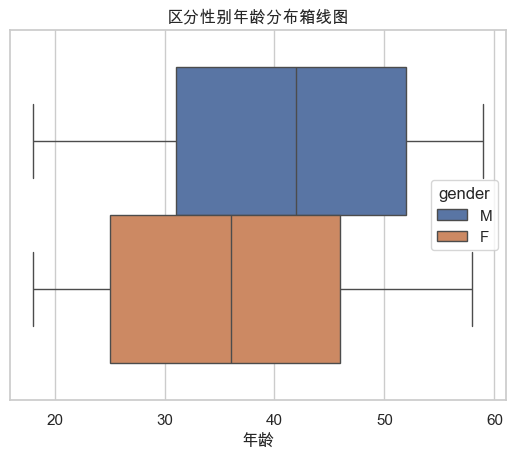

In [5]:
# [你的代码]
df_clean=df[df['weight'].between(0,200)]
sns.boxplot(data=df_clean,x='age',hue='gender')
plt.xlabel('年龄')
plt.title('区分性别年龄分布箱线图')

## 💡 模块 4: 参考答案 (点击展开)

In [ ]:
# Level 1
sns.histplot(data=df, x='age', bins=15)
plt.title('Age Distribution')

# Level 2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='height', y='weight', hue='gender', alpha=0.7)

# Level 3
df_clean = df[(df['weight'] > 0) & (df['weight'] < 200)]
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='gender', y='weight')